In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 


In [2]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')

S_plus = (S_X+1j*S_Y)/2
S_minus = (S_X-1j*S_Y)/2

paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

"""eigVals=np.array([0])
for i in range(100):
    [evals,evecs]=linalg.eig(mkU(100))
    eigVals = np.concatenate([eigVals,evals])
plt.hist(np.arctan(np.real(eigVals[1:])/np.imag(eigVals[1:])),20)"""


def mkLiouvillian(rate, dt, ldbldOp, debug): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    if debug == True: print(np.allclose(H, H.T.conj()) )    
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    if debug == True: print(np.allclose(G, G.T.conj()) )
        
    denseU=linalg.expm(G * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))   
    [eigVals, eigVecs] = linalg.eigh(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.bsr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps


In [3]:
def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


def mkGlobalKrausOps(layer, Nqubit, rate, dt, ldbldOp, debug=True):
    
    allKs = {}

    if np.mod(layer,2) == 0:    
        # position records the site with the non-trivial unitary
        
        positions = [i for i in range(0, Nqubit-1, 2)]
        
        for pos in positions:
            
            # one needs to make N/2 different random unitaries        
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp, debug))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))
        
        for pos in positions:  
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp, debug))
            allKs[pos] = []
            
            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]
                    
            else:
                # decomposition of Kraus is required with PBC
                
                k_abs = decompKrausOps(krausOps)
                
                for row in k_abs:

                    K_jk = sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):  
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128') 
                        U_chain[pos] = paulis[basisInd//4] 
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] 

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]   

    return allKs


In [17]:
mkGlobalKrausOps(layer=9, Nqubit=4, rate = 0.001, dt=3, ldbldOp=S_minus, debug=False)

{1: [<16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 128 stored elements (blocksize = 2x2) in Block Sparse Row format>,
  <16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 128 stored elements (blocksize = 2x2) in Block Sparse Row format>,
  <16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 128 stored elements (blocksize = 2x2) in Block Sparse Row format>,
  <16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 32 stored elements (blocksize = 2x2) in Block Sparse Row format>],
 3: [<16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 40 stored elements (blocksize = 1x1) in Block Sparse Row format>,
  <16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 40 stored elements (blocksize = 1x1) in Block Sparse Row format>,
  <16x16 sparse matrix of type '<class 'numpy.complex128'>'
  	with 56 stored elements (blocksize = 1x1) in Block Sparse Row format>,
  <16x16 sparse matrix of type '<class 'numpy.comple

In [5]:
# employ the faster Kraus Unitary sum
def evolveKrausU(allKs, rho, debug = True):
    
    Nqubit = int(np.log2(len(rho.toarray())))
 
    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()   
            
            if debug == True:
                print(np.trace(newRho.toarray()))
        
    return newRho


In [4]:
def calcS(densityM, Ntot,partiesToTraceOut=[0]):
    
    redRho = ptrace_rho(densityM, partiesToTraceOut)

    #redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [4]:
# Testing einsum partial trace function:

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 8
# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))


def ptrace_rho(operator, elements):    

    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    rho = np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(rho.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
            
    operator= np.einsum(rho, indexarr)
    length = len(operator.shape)
    halflength = length//2
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))


qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nq = 4
# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.bsr_matrix(reduce(sparse.kron, [state0rho]*Nq))

p_tr1 = ptrace_rho(rho.toarray(), [2])
p_tr2 = partial_trace(rho.toarray(), [3], [2] * Nq)



In [48]:
rho = sparse.bsr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

N=50
purities = np.zeros(N)
trace = np.zeros(N)
populations = np.zeros([1,2**Nqubit])

for s in range(N): 
    purities[s]=calcPurity(rho.toarray())
    trace[s]=np.trace(rho.toarray())
    
    allKrausOps = mkGlobalKrausOps(layer=s, Nqubit=8, rate=.1, dt=5, ldbldOp=S_minus, debug=False)
    # ok the trace is not 1
    rho = evolveKrausU(allKrausOps, rho, debug = False)

    populations = np.vstack([populations,np.linalg.eigh(rho.toarray())[0]])


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  if __name__ == '__main__':
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  # Remove the CWD from sys.path while we load stuff.


In [11]:
import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

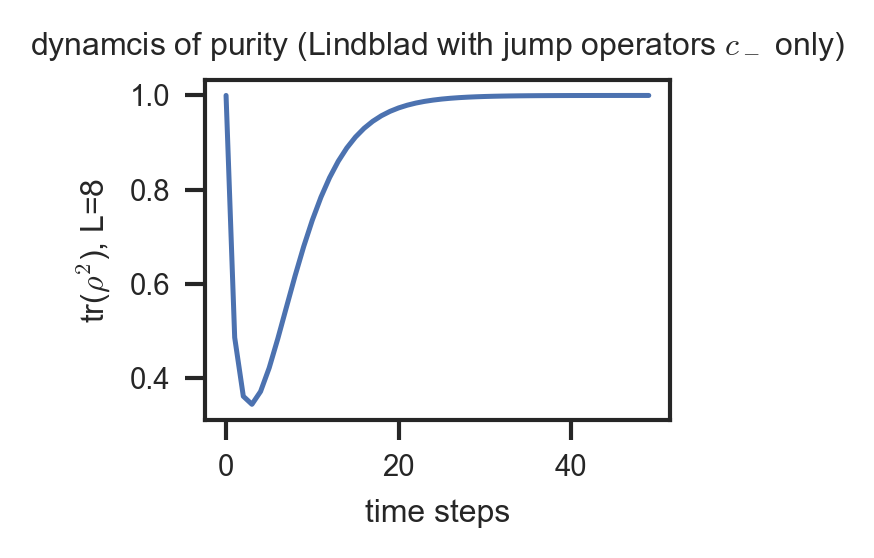

In [49]:
plt.figure()
plt.plot(purities)
plt.xlabel('time steps')
plt.ylabel(r'tr($\rho^2$), L=8')
plt.title('dynamcis of purity (Lindblad with jump operators $c_-$ only)')
print()

In [31]:
populations = populations[1:,:]

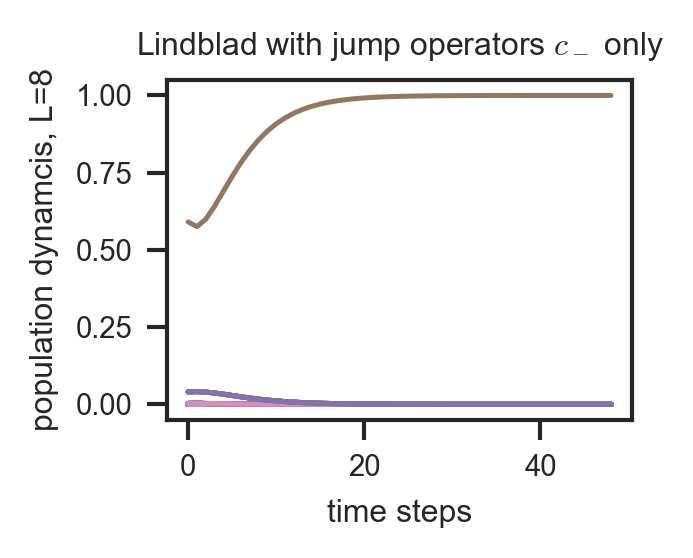

In [34]:
plt.figure()
plt.plot(populations[1:,:])
plt.xlabel('time steps')
plt.ylabel(r'population dynamcis, L=8')
plt.title('Lindblad with jump operators $c_-$ only')
print()